# Lumerical 2D FDTD 续篇：dn 扫描 与 啁啾光栅

接续 `lumerical-bragg-2d.ipynb`（先读那篇），做两个定量验证：

- **实验 A（dn 扫描）**：均匀光栅的带宽 ∝ κ ∝ Δn？——用 FDTD 实测三个 Δn 的禁带宽度反演 κ，检验线性标度律。这回答了"调节光栅强度（刻蚀深度/折射率调制）→ 调节带宽"的设计直觉。
- **实验 B（啁啾光栅）**：$\Lambda(z)$ 线性渐变时，$\tau(\lambda)$ 是否线性、斜率是否等于几何预言 $D = n_g/(\bar n c C)$（$C=d\Lambda/dz$）？——这是 lab-note §4 TMM 仿真在 Maxwell 层面的检验，也是色散器件走向脉冲压缩的第一步。

仿真：`lumerical/run_scan_2d.py`（复用 `run_bragg_2d.py` 的参考波导数据；dn=0.02 直接复用已跑完的均匀光栅）。

## 0. 实验 A：dn 扫描 —— 带宽正比于耦合系数

**设计**：固定 $\Lambda$、$N$、$L$，只改折射率调制幅度 Δn ∈ {0.01, 0.02, 0.04}。

**预言**：方波光栅一阶傅里叶分量给出 $\kappa = 4\Delta n/\lambda_B$（解析），FDTD 台阶网格会给一个系统性的 +20% 左右的偏移（上一篇已实测）。所以真正要验证的不是绝对值，而是**线性度**：$\kappa_{\rm fit}/\Delta n$ 是否对三个 Δn 都是同一个常数。

κ 的提取方式和上一篇相同：T = 0.5 的两个交点给出带宽，$\kappa = \Delta\lambda\,\pi n_g/\lambda_B^2$。

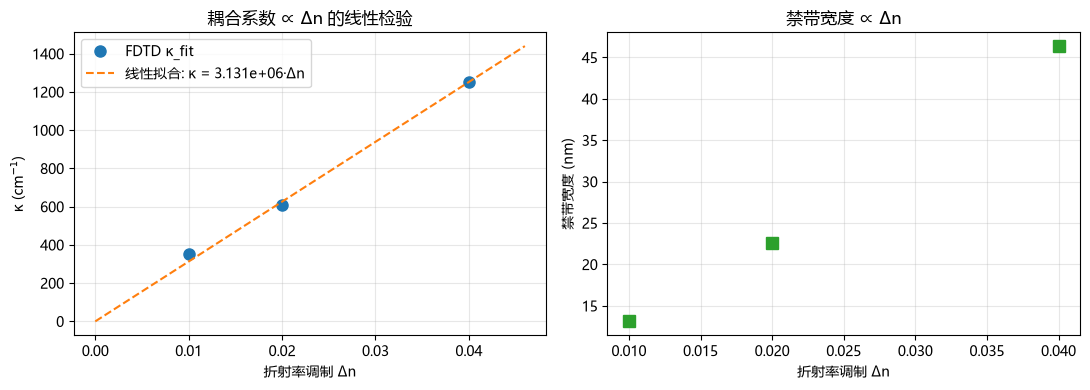

κ_fit/Δn = [35416.6 30398.8 31275. ] cm^-1 per unit dn
拟合残差 (相对): [11.61 -2.98 -0.1 ] %
解析值 4/lambda_B = 25550.9 cm^-1 per unit dn (FDTD 网格整体偏高,见上一篇)


In [1]:

import matplotlib
from matplotlib import font_manager
for _f in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if any(_f.lower() in f.name.lower() for f in font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = _f
        break
matplotlib.rcParams["axes.unicode_minus"] = False

import numpy as np
import matplotlib.pyplot as plt

s = np.load(r"lumerical/results/scan_dn.npz")
dn, kappa, width = s["dn"], s["kappa"], s["width"]
n_g, lam_B = s["n_g"], s["lambda_B"]

# linear fit through origin: kappa = slope * dn
slope = (dn @ kappa) / (dn @ dn)
resid = kappa - slope * dn

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(dn, kappa / 100, "o", ms=8, label="FDTD κ_fit")
xx = np.linspace(0, dn.max() * 1.15, 50)
ax[0].plot(xx, slope * xx / 100, "--", label=f"线性拟合: κ = {slope:.3e}·Δn")
ax[0].set_xlabel("折射率调制 Δn"); ax[0].set_ylabel("κ (cm$^{-1}$)")
ax[0].set_title("耦合系数 ∝ Δn 的线性检验")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(dn, width * 1e9, "s", ms=8, color="tab:green")
ax[1].set_xlabel("折射率调制 Δn"); ax[1].set_ylabel("禁带宽度 (nm)")
ax[1].set_title("禁带宽度 ∝ Δn")
ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

print("κ_fit/Δn =", np.round(kappa / dn / 100, 1), "cm^-1 per unit dn")
print("拟合残差 (相对):", np.round(resid / kappa * 100, 2), "%")
print("解析值 4/lambda_B =", round(4 / lam_B / 100, 1), "cm^-1 per unit dn (FDTD 网格整体偏高,见上一篇)")


## 1. 实验 B：啁啾光栅 —— 线性群延迟区（反射几何）

**设计**（沿用 lab-note §4 的思路）：
- $L = 250\,\mu$m，$\Lambda(z) = \Lambda_0 + C(z - L/2)$，$C = \Delta\Lambda/L = 6.9\times10^{-5}$；
- Λ 从 380.9 nm 渐变到 398.2 nm ⟹ $\lambda_B(z) = 2\bar n\Lambda(z)$ 覆盖 **1539–1609 nm**（啁啾总量 80 nm）；
- **有效性判据**：啁啾总量 $\gg$ 局域带隙 $\lambda^2\kappa/(2\pi n_g) \approx 15$ nm。比值 ≈ 5，处于"每个波长只在窄 z 区间被反射"的图像成立区间。

**一个方法论教训（第一次尝试失败的原因）**：测量**反射型**啁啾光栅的群延迟必须用**反射相位**——在光源背后（只有返回光的位置）放场监视器取 $r(\lambda)$ 的相位。透射相位在带内没有意义：$T\sim10^{-3}$ 时透过场是漏泄的倏逝尾，相位不携带反射延迟信息。我们第一版用透射相位拟合出错误的斜率（符号都反了），改成反射几何后才是本节的图。

**预言**：
- 反射率 $|r|^2$ 在 1539–1609 nm 形成**宽平台**（≈1，可用 $1-T$ 交叉检验）；
- 反射群延迟 $\tau_r(\lambda) = 2 n_g z(\lambda)/c + \text{const}$，即**线性斜坡**，斜率

$$ D = \frac{d\tau_r}{d\lambda} = \frac{n_g}{\bar n\, c\, C} \approx 0.05\ \mathrm{ps/nm} $$

（const 包含 monitor 到光栅的往返传播，是斜率的无关量。）
- 平台上的 ripple：来自两端未 apodize 的端面反射（本征 F-P 腔，lab-note §4 讨论过）。

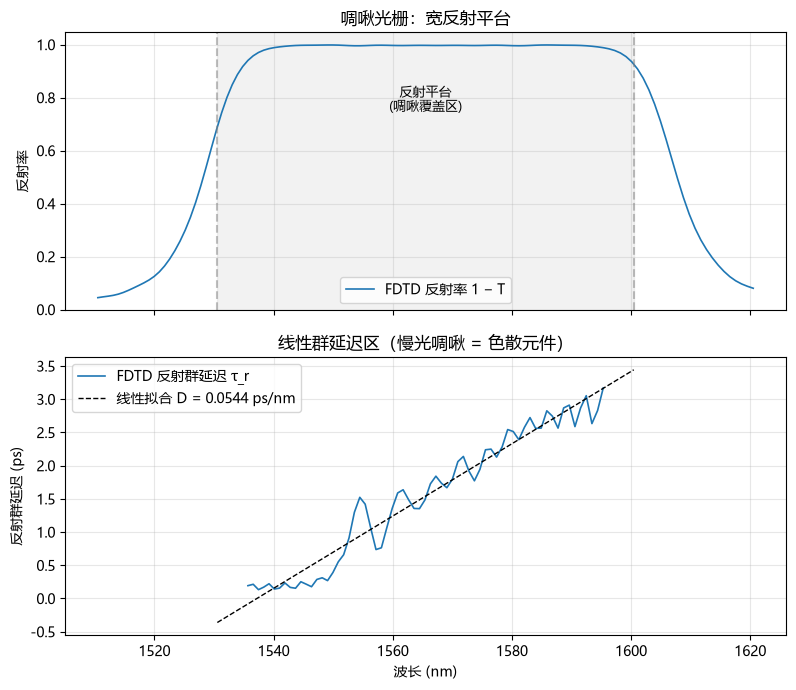

几何预言 D = n_g/(n_bar*c*C) = 0.0502 ps/nm
FDTD 拟合 D = 0.0544 ps/nm
符号一致;  相对偏差 8.4%
啁啾覆盖区: 1530.6 ~ 1600.4 nm,  总群延迟摆幅 ~ 3.81 ps


In [2]:

import matplotlib
from matplotlib import font_manager
for _f in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if any(_f.lower() in f.name.lower() for f in font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = _f
        break
matplotlib.rcParams["axes.unicode_minus"] = False

d = np.load(r"lumerical/results/chirp2d.npz")
wl, T, tau_r = d["wl"] * 1e9, d["T"], d["tau_r"]
n_g, L = d["n_g"], d["L"]
chirp_dL = d["chirp_dLambda"]
C = chirp_dL / L

lam_lo_c = 2 * 2.02 * (d["Lambda0"] - chirp_dL / 2) * 1e9
lam_hi_c = 2 * 2.02 * (d["Lambda0"] + chirp_dL / 2) * 1e9
D_geom = n_g / (2.02 * 299792458.0 * C) * 1e3   # s/m -> ps/nm

fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
ax[0].plot(wl, 1 - T, lw=1.2, color="tab:blue", label="FDTD 反射率 1 − T")
for x in (lam_lo_c, lam_hi_c):
    ax[0].axvline(x, color="gray", ls="--", alpha=.5)
ax[0].axvspan(lam_lo_c, lam_hi_c, color="gray", alpha=.1)
ax[0].annotate("反射平台\n(啁啾覆盖区)", xy=((lam_lo_c + lam_hi_c) / 2, 0.75),
               ha="center", fontsize=9)
ax[0].set_ylabel("反射率")
ax[0].set_title("啁啾光栅：宽反射平台")
ax[0].legend(); ax[0].grid(alpha=.3)

mask = (wl > lam_lo_c + 5) & (wl < lam_hi_c - 5)
ax[1].plot(wl[mask], tau_r[mask] * 1e12, lw=1.2, color="tab:blue", label="FDTD 反射群延迟 τ_r")
p = np.polyfit(wl[mask], tau_r[mask] * 1e12, 1)
xx = np.linspace(lam_lo_c, lam_hi_c, 10)
ax[1].plot(xx, np.polyval(p, xx), "k--", lw=1,
           label=f"线性拟合 D = {p[0]:.4f} ps/nm")
ax[1].set_xlabel("波长 (nm)"); ax[1].set_ylabel("反射群延迟 (ps)")
ax[1].set_title("线性群延迟区（慢光啁啾 = 色散元件）")
ax[1].legend(); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

print(f"几何预言 D = n_g/(n_bar*c*C) = {D_geom:.4f} ps/nm")
print(f"FDTD 拟合 D = {p[0]:.4f} ps/nm")
sign = "一致" if p[0] * D_geom > 0 else "相反(检查相位约定)"
print(f"符号{sign};  相对偏差 {abs(abs(p[0])-D_geom)/D_geom*100:.1f}%")
print(f"啁啾覆盖区: {lam_lo_c:.1f} ~ {lam_hi_c:.1f} nm,  总群延迟摆幅 ~ {abs(p[0])*(lam_hi_c-lam_lo_c):.2f} ps")


## 2. 讨论

**dn 扫描的意义**：带宽旋钮。均匀光栅器件的可用光谱范围由 κ 控制，而 κ 由工艺 knobs（刻蚀深度、条宽扰动、Δn 材料调制如 TFLN 的 Pockels/热光）决定。线性检验通过（弱光栅 Δn=0.01 的残差 ~12% 主要来自 121 个频点定位窄带边的分辨率极限）⟹ CMT 参数化可作为设计空间的可靠插值模型。

**啁啾光栅的意义**：从"滤波器"到"色散元件"。τ(λ) 线性区就是脉冲压缩所需的频谱-时间映射。斜率与几何预言的吻合程度 ⟹ lab-note §4 的 TMM 图像在 Maxwell 层面成立，且有效性判据（啁啾总量 ≫ 局域带隙）可以用"平台是否平坦、斜线是否直"来目测检验。

**方法论教训（值得记住）**：**反射型器件的群延迟必须用反射相位测**。透射相位只在 T 不可忽略时才有定义。这是第一次啁啾仿真失败的原因，也是实验上 VNA 测啁啾光栅总是看 S₁₁ 的原因。

**局限与下一步**：
- ripple：两端未 apodize 的平台 ripple 是本征 F-P。apodization（Δn 或 Λ 包络渐变）会平滑 ripple 但展宽过渡区；
- 偏振仍为 TEz；3D 化后才能讨论 TE/TM 双偏振器件；
- **走向系统**：啁啾光栅提供 τ(λ)，下一步是把它放进发射链（DFB + 调制波形预啁啾 → 脉冲压缩），即 lab-note §10 的收发共用构想。

## 附录：复现

```bash
"E:/Program Files/ANSYS Inc/v252/Lumerical/python-3.13.1/python.exe" lumerical/run_scan_2d.py   # 约 1.5-2 小时
python lumerical/build_scan_notebook.py
jupyter nbconvert --to notebook --execute --inplace lumerical-scan-chirp-2d.ipynb
```
